In [ ]:
!pip install waymo-open-dataset-tf-2-12-0 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 17.0 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
from waymo_open_dataset import dataset_pb2 as open_dataset
from waymo_open_dataset.utils import frame_utils
from waymo_open_dataset.protos import scenario_pb2

SEGMENT_PATH = '/content/individual_files_validation_segment-10203656353524179475_7625_000_7645_000_with_camera_labels.tfrecord'
dataset = tf.data.TFRecordDataset(SEGMENT_PATH, compression_type='')


check number of frames

In [ ]:
num_records = sum(1 for _ in dataset)
num_records

198

In [ ]:
frames = []

for data in dataset:
  frame = open_dataset.Frame()
  frame.ParseFromString(bytearray(data.numpy()))
  frames.append(frame)

print(f"Frames in this segment: {len(frames)}")
frame = frames[0]
print(f"Timestamp: {frame.timestamp_micros}")
print(f"LiDAR sensors present: {[c.name for c in frame.context.laser_calibrations]}")


Frames in this segment: 198
Timestamp: 1522688014970187
LiDAR sensors present: [2, 5, 3, 4, 1]


In [ ]:
open_dataset.LaserName.Name.Name(3)


'SIDE_LEFT'

In [ ]:
for laser in frame.lasers:
    name = open_dataset.LaserName.Name.Name(laser.name)
    has_data = len(laser.ri_return1.range_image_compressed) > 0
    print(f"{name:12s} | has range image: {has_data}")

# Peek at one calibration entry
top_calib = [c for c in frame.context.laser_calibrations if c.name == open_dataset.LaserName.TOP][0]
print("Beam inclinations (TOP):", np.round(top_calib.beam_inclinations[:5], 4), "...")
print("Extrinsic transform shape:", np.array(top_calib.extrinsic.transform).shape)

TOP          | has range image: True
FRONT        | has range image: True
SIDE_LEFT    | has range image: True
SIDE_RIGHT   | has range image: True
REAR         | has range image: True
Beam inclinations (TOP): [-0.3095 -0.2985 -0.2878 -0.2777 -0.267 ] ...
Extrinsic transform shape: (16,)


In [ ]:
(range_images, camera_projections, _, range_image_top_pose) = (
    frame_utils.parse_range_image_and_camera_projection(frame)
)

points, points_cp = frame_utils.convert_range_image_to_point_cloud(
    frame,
    range_images,
    camera_projections,
    range_image_top_pose,
    ri_index=0,  # first return; some beams give a second ("ri_index=1") for transparent surfaces
)

# points is a list of arrays, one per laser — concatenate into one point cloud
points_all = np.concatenate(points, axis=0)
print(f"Total points this frame: {points_all.shape[0]:,}")
print(f"Sample point (x, y, z): {points_all[0]}")


Total points this frame: 124,102
Sample point (x, y, z): [-45.908447    8.347168    4.2639313]


Range image shape (rows=beams, cols=azimuth): (64, 2650)


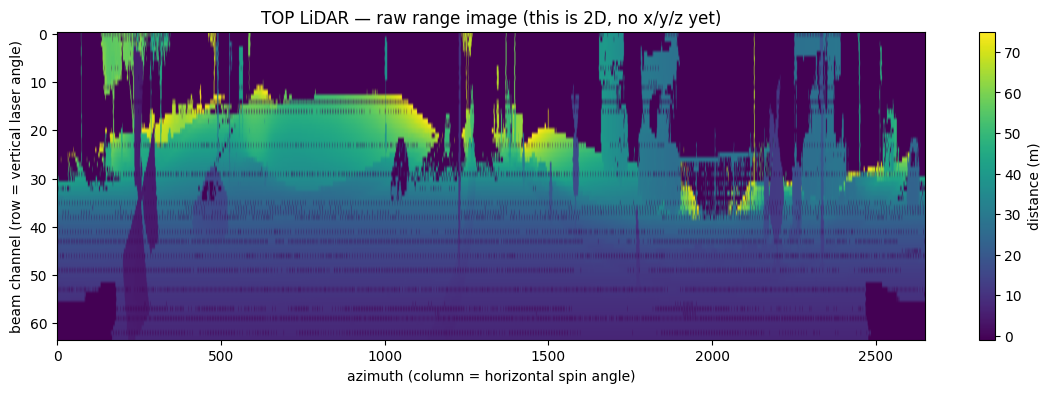

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

top_range_image = range_images[open_dataset.LaserName.TOP][0]

ri_tensor = tf.reshape(
    tf.convert_to_tensor(top_range_image.data), top_range_image.shape.dims
)

# Channel 0 = range (distance). Channels 1-3 are intensity, elongation, is-no-label-zone flag.
range_channel = ri_tensor[..., 0].numpy()

print("Range image shape (rows=beams, cols=azimuth):", range_channel.shape)

plt.figure(figsize=(14, 4))
plt.imshow(range_channel, cmap="viridis", aspect="auto")
plt.colorbar(label="distance (m)")
plt.xlabel("azimuth (column = horizontal spin angle)")
plt.ylabel("beam channel (row = vertical laser angle)")
plt.title("TOP LiDAR — raw range image (this is 2D, no x/y/z yet)")
plt.show()

In [ ]:
import plotly.graph_objects as go


top_range_image = range_images[open_dataset.LaserName.TOP][0]
ri_tensor = tf.reshape(
    tf.convert_to_tensor(top_range_image.data), top_range_image.shape.dims
)
# Channels: [range, intensity, elongation, is_in_no_label_zone]
intensity = ri_tensor[..., 1].numpy()
print("Range image shape (rows=channels, cols=azimuth):", ri_tensor.shape)

sample_idx = np.random.choice(len(points_all), size=min(40000, len(points_all)), replace=False)
pts = points_all[sample_idx]

fig = go.Figure(data=[go.Scatter3d(
    x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
    mode="markers",
    marker=dict(
        size=1.5,
        color=pts[:, 2],          # color by height
        colorscale="Viridis",
        colorbar=dict(title="height (m)"),
    ),
)])


fig.update_layout(
    scene=dict(aspectmode="data"),
    title="LiDAR Point Cloud — single frame, colored by height",
    height=700,
)

fig.show()


Range image shape (rows=channels, cols=azimuth): (64, 2650, 4)


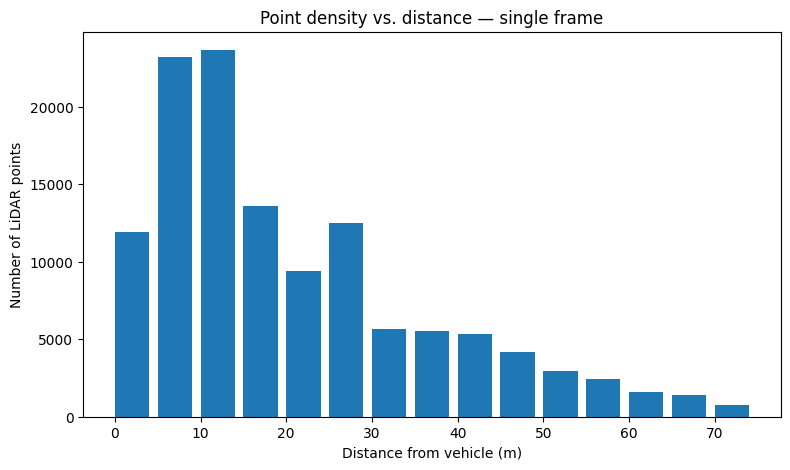

Points in the 48-52m ring: 2764 across the ENTIRE ring
A single pedestrian occupies a tiny fraction of that ring —
this is why classification gets unreliable at range.


In [ ]:
distances = np.linalg.norm(points_all[:, :2], axis=1)  # x,y only (ground-plane range)

bins = np.arange(0, 80, 5)  # 5m bins out to 80m
bin_idx = np.digitize(distances, bins)
counts_per_bin = [np.sum(bin_idx == i) for i in range(1, len(bins))]

plt.figure(figsize=(9, 5))
plt.bar(bins[:-1], counts_per_bin, width=4, align="edge")
plt.xlabel("Distance from vehicle (m)")
plt.ylabel("Number of LiDAR points")
plt.title("Point density vs. distance — single frame")
plt.show()

# Concrete talking-point number: points within a typical pedestrian-sized box at ~50m
far_zone = points_all[(distances > 48) & (distances < 52)]
print(f"Points in the 48-52m ring: {len(far_zone)} across the ENTIRE ring")
print("A single pedestrian occupies a tiny fraction of that ring —")
print("this is why classification gets unreliable at range.")

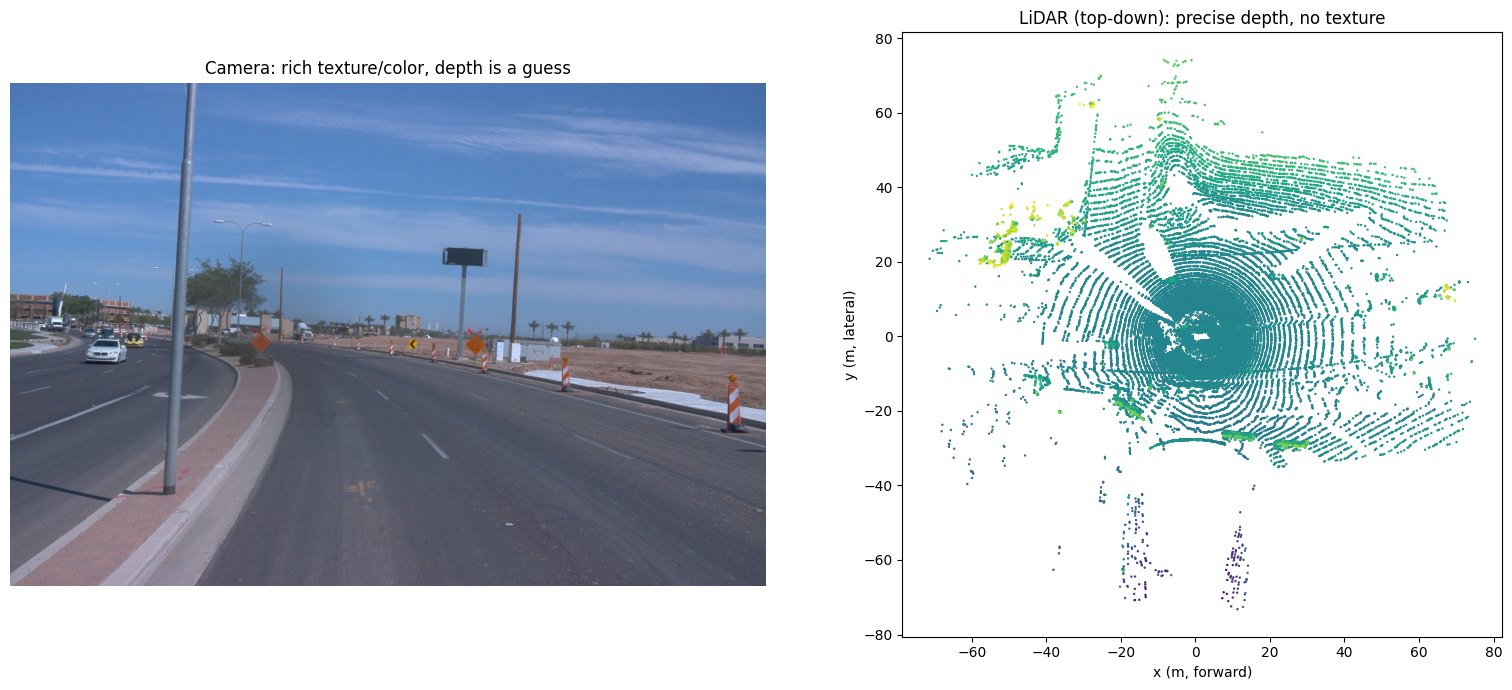

In [ ]:
import io
from PIL import Image

# Grab the matching front camera image for the same frame
front_image = [img for img in frame.images if img.name == open_dataset.CameraName.FRONT][0]
cam_img = Image.open(io.BytesIO(front_image.image))

fig4, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(cam_img)
axes[0].set_title("Camera: rich texture/color, depth is a guess")
axes[0].axis("off")

# Simple top-down LiDAR view for direct visual contrast
axes[1].scatter(pts[:, 0], pts[:, 1], s=0.5, c=pts[:, 2], cmap="viridis")
axes[1].set_title("LiDAR (top-down): precise depth, no texture")
axes[1].set_xlabel("x (m, forward)")
axes[1].set_ylabel("y (m, lateral)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()